In [1]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

In [2]:
# Set or create an experiment
mlflow.set_experiment("ML Algos with HP Tuning")

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/901947899065852447'), creation_time=1778952120616, experiment_id='901947899065852447', last_update_time=1778952120616, lifecycle_stage='active', name='ML Algos with HP Tuning', tags={}, trace_location=None, workspace='default'>

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import optuna


In [4]:
df = pd.read_csv('reddit_preprocessing.csv').dropna()
df.shape

(36662, 2)

[I 2026-05-17 14:58:44,740] A new study created in memory with name: no-name-c84ec9fd-6224-4f9c-9283-1038d65d0dd6
[I 2026-05-17 14:59:21,030] Trial 0 finished with value: 0.6869722480033458 and parameters: {'C': 0.08687657148746188, 'penalty': 'l1'}. Best is trial 0 with value: 0.6869722480033458.
[I 2026-05-17 14:59:39,200] Trial 1 finished with value: 0.7063975188900213 and parameters: {'C': 0.027192309001970137, 'penalty': 'l2'}. Best is trial 1 with value: 0.7063975188900213.
[I 2026-05-17 14:59:57,567] Trial 2 finished with value: 0.8173144879827781 and parameters: {'C': 0.8167481019771341, 'penalty': 'l2'}. Best is trial 2 with value: 0.8173144879827781.
[I 2026-05-17 15:00:15,507] Trial 3 finished with value: 0.8149585056388686 and parameters: {'C': 0.7355081333327871, 'penalty': 'l2'}. Best is trial 2 with value: 0.8173144879827781.
[I 2026-05-17 15:00:34,046] Trial 4 finished with value: 0.5533065899037888 and parameters: {'C': 0.0283958842463828, 'penalty': 'l1'}. Best is tri

BEST PARAMETERS
{'C': 1.5460728466380134, 'penalty': 'l1'}


c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Accuracy    : 0.8715
Macro F1    : 0.8620
Weighted F1 : 0.8710

Classification Report:

              precision    recall  f1-score   support

          -1       0.81      0.80      0.80      1650
           0       0.85      0.96      0.90      2529
           1       0.93      0.84      0.88      3154

    accuracy                           0.87      7333
   macro avg       0.86      0.87      0.86      7333
weighted avg       0.87      0.87      0.87      7333



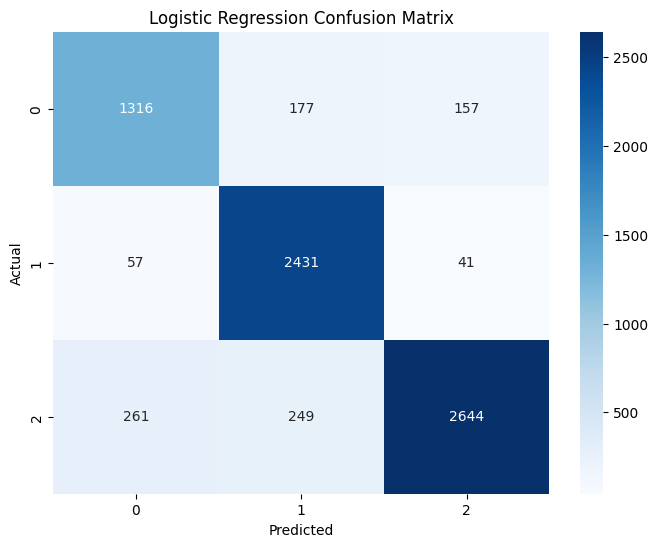

2026/05/17 16:10:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/17 16:11:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [6]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import optuna
import mlflow

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)

# =========================================================
# REMOVE NaN TARGETS
# =========================================================
df = df.dropna(
    subset=['category']
)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train_text, X_test_text, y_train, y_test = train_test_split(

    df['clean_comment'],
    df['category'],

    test_size=0.2,

    random_state=42,

    stratify=df['category']
)

# =========================================================
# TF-IDF SETTINGS
# =========================================================
ngram_range = (1, 3)

max_features = 5000

# =========================================================
# CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective_logreg(trial):

    params = {

        "C": trial.suggest_float(
            'C',
            1e-4,
            10.0,
            log=True
        ),

        "penalty": trial.suggest_categorical(
            'penalty',
            ['l1', 'l2']
        ),

        # FIXED
        "solver": "saga",

        "class_weight": "balanced",

        # IMPORTANT
        "max_iter": 5000,

        "random_state": 42
    }

    # =====================================================
    # PIPELINE
    # =====================================================
    pipeline = Pipeline([

        (
            "tfidf",

            TfidfVectorizer(

                ngram_range=ngram_range,

                max_features=max_features,

                min_df=2,

                max_df=0.95
            )
        ),

        (
            "model",

            LogisticRegression(
                **params
            )
        )
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================
    scores = cross_val_score(

        pipeline,

        X_train_text,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=4
    )

    return np.mean(scores)

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(
    direction="maximize"
)

study.optimize(

    objective_logreg,

    n_trials=30
)

# =========================================================
# BEST PARAMETERS
# =========================================================
print("=" * 60)

print("BEST PARAMETERS")

print(study.best_params)

print("=" * 60)

# =========================================================
# FINAL PIPELINE
# =========================================================
best_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            ngram_range=ngram_range,

            max_features=max_features,

            min_df=2,

            max_df=0.95
        )
    ),

    (
        "model",

        LogisticRegression(

            **study.best_params,

            # FIXED
            solver='saga',

            class_weight='balanced',

            # IMPORTANT
            max_iter=5000,

            random_state=42
        )
    )
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================
best_pipeline.fit(

    X_train_text,

    y_train
)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = best_pipeline.predict(
    X_test_text
)

# =========================================================
# METRICS
# =========================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(

    y_test,

    y_pred,

    average='macro'
)

weighted_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

# =========================================================
# RESULTS
# =========================================================
print(f"Accuracy    : {accuracy:.4f}")

print(f"Macro F1    : {macro_f1:.4f}")

print(f"Weighted F1 : {weighted_f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# =========================================================
# MLFLOW LOGGING
# =========================================================
with mlflow.start_run():

    # -----------------------------------------------------
    # TAGS
    # -----------------------------------------------------
    mlflow.set_tag(
        "model",
        "LogisticRegression"
    )

    mlflow.set_tag(
        "vectorizer",
        "TF-IDF"
    )

    # -----------------------------------------------------
    # PARAMETERS
    # -----------------------------------------------------
    mlflow.log_param(
        "ngram_range",
        ngram_range
    )

    mlflow.log_param(
        "max_features",
        max_features
    )

    mlflow.log_params(
        study.best_params
    )

    # -----------------------------------------------------
    # METRICS
    # -----------------------------------------------------
    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "macro_f1",
        macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        weighted_f1
    )

    # -----------------------------------------------------
    # CLASSIFICATION REPORT
    # -----------------------------------------------------
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    for label, metrics in report.items():

        if isinstance(metrics, dict):

            for metric_name, metric_value in metrics.items():

                mlflow.log_metric(
                    f"{label}_{metric_name}",
                    metric_value
                )

    # -----------------------------------------------------
    # SAVE MODEL
    # -----------------------------------------------------
    mlflow.sklearn.log_model(

        best_pipeline,

        "logistic_regression_pipeline"
    )